In [3]:
import pandas as pd

ddd = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\DDD.csv")

print(ddd.shape)
print(ddd.columns.tolist())

(4969, 37)
['code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'date_registration', 'date_unregistration', 'ass_1_date', 'ass_1_score', 'ass_2_date', 'ass_2_score', 'ass_3_date', 'ass_3_score', 'ass_4_date', 'ass_4_score', 'ass_5_date', 'ass_5_score', 'ass_6_date', 'ass_6_score', 'ass_7_date', 'ass_7_score', 'clicks_externalquiz', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouwiki', 'clicks_resource', 'clicks_subpage', 'clicks_url']


In [5]:
demographics = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
                 'num_of_prev_attempts', 'studied_credits', 'disability']

assessment_cols = [f'ass_{i}_score' for i in range(1, 8)]

click_cols = ['clicks_externalquiz', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage',
              'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouwiki', 'clicks_resource',
              'clicks_subpage', 'clicks_url']

selected_cols = demographics + assessment_cols + click_cols + ['final_result']

ddd_sel = ddd[selected_cols].copy()
print(ddd_sel.shape)
ddd_sel.head()

(4969, 26)


,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,ass_1_score,ass_2_score,...,clicks_forumng,clicks_glossary,clicks_homepage,clicks_oucollaborate,clicks_oucontent,clicks_ouwiki,clicks_resource,clicks_subpage,clicks_url,final_result
0,M,South Region,HE Qualification,90-100%,55<=,0,60,N,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Withdrawn
1,M,London Region,HE Qualification,30-40%,55<=,0,90,N,93.0,83.0,...,36.0,0.0,184.0,12.0,64.0,18.0,70.0,227.0,23.0,Withdrawn
2,M,South West Region,Lower Than A Level,60-70%,0-35,0,60,N,48.0,58.0,...,142.0,0.0,99.0,5.0,55.0,36.0,45.0,20.0,7.0,Withdrawn
3,F,East Anglian Region,Lower Than A Level,30-40%,0-35,0,60,Y,75.0,73.0,...,142.0,0.0,259.0,2.0,64.0,38.0,41.0,231.0,33.0,Fail
4,F,Yorkshire Region,HE Qualification,10-20,35-55,0,70,N,58.0,57.0,...,92.0,0.0,162.0,0.0,100.0,75.0,32.0,175.0,15.0,Fail


In [7]:
print("imd_band unique values:")
print(ddd_sel['imd_band'].unique())
print()
print("imd_band NaN count:", ddd_sel['imd_band'].isna().sum())
print()
print("NaN counts - assessment scores:")
print(ddd_sel[assessment_cols].isna().sum())
print()
print("NaN counts - click columns:")
print(ddd_sel[click_cols].isna().sum())

imd_band unique values:
['90-100%' '30-40%' '60-70%' '10-20' '80-90%' '0-10%' '40-50%' '50-60%'
 '20-30%' '70-80%' nan]

imd_band NaN count: 219

NaN counts - assessment scores:
ass_1_score    1136
ass_2_score    1558
ass_3_score    1800
ass_4_score    2104
ass_5_score    2433
ass_6_score    2765
ass_7_score    2527
dtype: int64

NaN counts - click columns:
clicks_externalquiz     438
clicks_forumng          438
clicks_glossary         438
clicks_homepage         438
clicks_oucollaborate    438
clicks_oucontent        438
clicks_ouwiki           438
clicks_resource         438
clicks_subpage          438
clicks_url              438
dtype: int64


In [9]:
# Fix imd_band missing % bug
ddd_sel['imd_band'] = ddd_sel['imd_band'].replace('10-20', '10-20%')

# Mode-fill imd_band NaN
imd_mode = ddd_sel['imd_band'].mode()[0]
print("imd_band mode:", imd_mode)
ddd_sel['imd_band'] = ddd_sel['imd_band'].fillna(imd_mode)

print(ddd_sel['imd_band'].unique())

# Sanity check: all-or-nothing NaN pattern across clicks?
click_nan_mask = ddd_sel[click_cols].isna()
same_students = (click_nan_mask.sum(axis=1).isin([0, 10])).all()
print("All-or-nothing NaN pattern across clicks:", same_students)

# Impute
ddd_sel[assessment_cols] = ddd_sel[assessment_cols].fillna(-1)
ddd_sel[click_cols] = ddd_sel[click_cols].fillna(0)

print(ddd_sel.isna().sum().sum())

imd_band mode: 30-40%
['90-100%' '30-40%' '60-70%' '10-20%' '80-90%' '0-10%' '40-50%' '50-60%'
 '20-30%' '70-80%']
All-or-nothing NaN pattern across clicks: True
0


In [11]:
final_result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
ddd_sel['final_result'] = ddd_sel['final_result'].map(final_result_map)

highest_ed_order = ['No Formal quals', 'Lower Than A Level', 'A Level or Equivalent',
                     'HE Qualification', 'Post Graduate Qualification']
highest_ed_map = {v: i for i, v in enumerate(highest_ed_order)}
ddd_sel['highest_education'] = ddd_sel['highest_education'].map(highest_ed_map)

imd_order = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%',
             '60-70%', '70-80%', '80-90%', '90-100%']
imd_map = {v: i for i, v in enumerate(imd_order)}
ddd_sel['imd_band'] = ddd_sel['imd_band'].map(imd_map)

age_band_order = ['0-35', '35-55', '55<=']
age_band_map = {v: i for i, v in enumerate(age_band_order)}
ddd_sel['age_band'] = ddd_sel['age_band'].map(age_band_map)

ddd_sel['gender'] = ddd_sel['gender'].map({'M': 0, 'F': 1})
ddd_sel['disability'] = ddd_sel['disability'].map({'N': 0, 'Y': 1})

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
ddd_sel['region'] = le.fit_transform(ddd_sel['region'])

print(ddd_sel.isna().sum().sum())
print(ddd_sel.dtypes)

0
gender                    int64
region                    int64
highest_education         int64
imd_band                  int64
age_band                  int64
num_of_prev_attempts      int64
studied_credits           int64
disability                int64
ass_1_score             float64
ass_2_score             float64
ass_3_score             float64
ass_4_score             float64
ass_5_score             float64
ass_6_score             float64
ass_7_score             float64
clicks_externalquiz     float64
clicks_forumng          float64
clicks_glossary         float64
clicks_homepage         float64
clicks_oucollaborate    float64
clicks_oucontent        float64
clicks_ouwiki           float64
clicks_resource         float64
clicks_subpage          float64
clicks_url              float64
final_result              int64
dtype: object


In [13]:
for col in click_cols:
    nonzero = (ddd_sel[col] != 0).sum()
    unique_vals = ddd_sel[col].nunique()
    print(f"{col}: {nonzero} nonzero / {unique_vals} unique values")

clicks_externalquiz: 3779 nonzero / 86 unique values
clicks_forumng: 4019 nonzero / 945 unique values
clicks_glossary: 1460 nonzero / 162 unique values
clicks_homepage: 4527 nonzero / 834 unique values
clicks_oucollaborate: 3073 nonzero / 133 unique values
clicks_oucontent: 4404 nonzero / 504 unique values
clicks_ouwiki: 2369 nonzero / 292 unique values
clicks_resource: 4302 nonzero / 261 unique values
clicks_subpage: 4407 nonzero / 655 unique values
clicks_url: 4003 nonzero / 173 unique values


In [15]:
ddd_sel['total_clicks'] = ddd_sel[click_cols].sum(axis=1)
ddd_sel = ddd_sel.drop(columns=click_cols)

bin_cols = assessment_cols + ['total_clicks']

for col in bin_cols:
    binned = pd.qcut(ddd_sel[col], q=4, duplicates='drop')
    n_bins = binned.nunique()
    print(f"{col}: {n_bins} bins")
    ddd_sel[col] = binned.cat.codes

print()
print("Final shape:", ddd_sel.shape)
print(ddd_sel.columns.tolist())

ass_1_score: 4 bins
ass_2_score: 3 bins
ass_3_score: 3 bins
ass_4_score: 3 bins
ass_5_score: 3 bins
ass_6_score: 2 bins
ass_7_score: 2 bins
total_clicks: 4 bins

Final shape: (4969, 17)
['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_6_score', 'ass_7_score', 'final_result', 'total_clicks']


In [17]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
import numpy as np

data = ddd_sel.values.astype(float)
node_names = ddd_sel.columns.tolist()

nodes = {name: GraphNode(name) for name in node_names}

assessment_cols_ddd = [f'ass_{i}_score' for i in range(1, 8)]
demo_vars = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
             'num_of_prev_attempts', 'studied_credits', 'disability']
course_time_vars = assessment_cols_ddd + ['total_clicks', 'final_result']

bk = BackgroundKnowledge()

# Rule 1: course-time variables cannot cause demographics
for ct in course_time_vars:
    for d in demo_vars:
        bk.add_forbidden_by_node(nodes[ct], nodes[d])

# Rule 2: nothing can cause gender (pure root)
for name in node_names:
    if name != 'gender':
        bk.add_forbidden_by_node(nodes[name], nodes['gender'])

# Rule 3: assessments must respect sequential order
for i in range(1, 8):
    for j in range(1, 8):
        if j > i:
            bk.add_forbidden_by_node(nodes[f'ass_{j}_score'], nodes[f'ass_{i}_score'])

# Rule 4: course-time variables cannot cause studied_credits/num_of_prev_attempts
for ct in course_time_vars:
    bk.add_forbidden_by_node(nodes[ct], nodes['studied_credits'])
    bk.add_forbidden_by_node(nodes[ct], nodes['num_of_prev_attempts'])

# Rule 5: final_result cannot cause any assessment score
for a in assessment_cols_ddd:
    bk.add_forbidden_by_node(nodes['final_result'], nodes[a])

# Rule 6: assessment scores cannot cause total_clicks
for a in assessment_cols_ddd:
    bk.add_forbidden_by_node(nodes[a], nodes['total_clicks'])

# Rule 7: final_result cannot cause total_clicks
bk.add_forbidden_by_node(nodes['final_result'], nodes['total_clicks'])

cg = pc(data, alpha=0.05, indep_test='gsq', background_knowledge=bk, node_names=node_names)

print("PC complete.")
print("Number of edges:", cg.G.get_num_edges())

  0%|          | 0/17 [00:00<?, ?it/s]

PC complete.
Number of edges: 38


In [19]:
edges = cg.G.get_graph_edges()
for edge in edges:
    print(edge)

gender --> age_band
gender --> studied_credits
gender --> disability
gender --> total_clicks
highest_education --> region
imd_band --> region
disability --> region
age_band --> highest_education
highest_education --> disability
age_band --> total_clicks
num_of_prev_attempts --> total_clicks
ass_1_score --> ass_2_score
ass_1_score --> ass_3_score
ass_1_score --> ass_4_score
ass_1_score --> ass_5_score
ass_1_score --> ass_7_score
ass_1_score --> final_result
total_clicks --> ass_1_score
ass_2_score --> ass_3_score
ass_2_score --> ass_4_score
ass_2_score --> ass_5_score
total_clicks --> ass_2_score
ass_3_score --> ass_4_score
ass_3_score --> ass_5_score
ass_3_score --> ass_7_score
ass_3_score --> final_result
total_clicks --> ass_3_score
ass_4_score --> ass_5_score
ass_4_score --> ass_6_score
ass_4_score --> ass_7_score
ass_4_score --> final_result
total_clicks --> ass_4_score
ass_5_score --> ass_6_score
ass_5_score --> final_result
total_clicks --> ass_5_score
ass_6_score --> final_resul

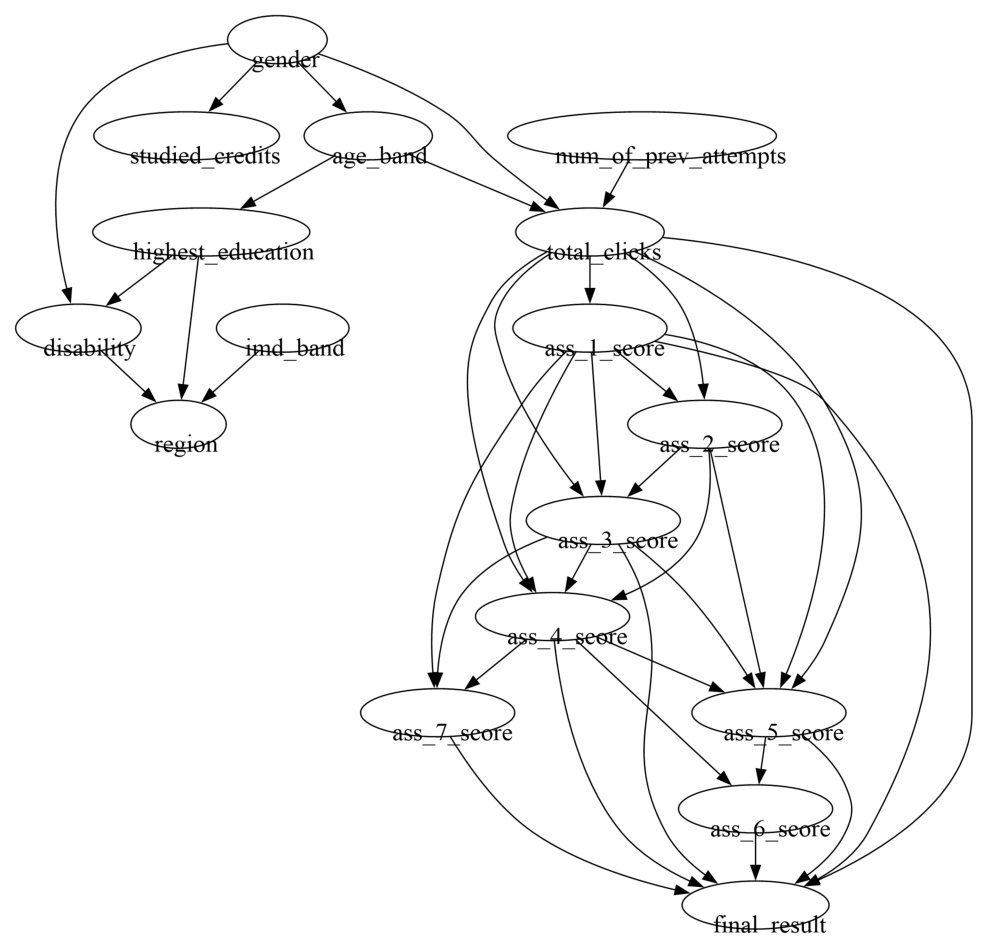

In [21]:
from causallearn.utils.GraphUtils import GraphUtils
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import io

dot_path = r"C:\Users\Disha Sharma\.conda\envs\analytics\Library\bin\dot.exe"

pyd = GraphUtils.to_pydot(cg.G, labels=node_names)
png_data = pyd.create_png(prog=dot_path)

img = mpimg.imread(io.BytesIO(png_data))
plt.figure(figsize=(16, 12))
plt.imshow(img)
plt.axis('off')
plt.show()